<a href="https://colab.research.google.com/github/Squad-Nina-da-Hora/wmc-desafio-previsao-demencia/blob/main/analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análise de Previsão de Demência**
---


🎯 **Objetivo:**  Prever sinais de demência, através de informações clínicas e demográficas de pacientes com potencial risco de Alzheimer (OASIS).


---


Desafio Estatística com Python - Classificação

Squad Nina da Hora | Bootcamp Data Analytics 2026.1

## 1. Configurações Iniciais

Variáveis da base de dados:

- `Subject ID`: Identificador único do paciente
- `MRI ID`: Identificador único do exame
- `Group` (alvo): Classificação do paciente
  - `Nondemented` - será tratada para variável binária 0
  - `Demented` e `Converted` - serão tratadas para variável binária 1
- `Visit`: Identificador da visita de cada paciente
- `MR Delay`: Intervalo em dias entre os exames
- `M/F`: Gênero (M: masculino, F: feminino)
- `Hand`: Mão dominante
- `Age`: Idade do paciente (numérico)
- `EDUC`: Anos de escolaridade (numérico)
- `SES`: Status socioeconômico (1 a 5)
- `MMSE`: Escore do Mini Exame do Estado Mental (0 a 30)
- `CDR`: Clinical Dementia Rating (0 a 3)
- `eTIV`: Volume intracraniano estimado
- `nWBV`: Proporção de volume cerebral normalizado
- `ASF`: Fator de escala anatômica

In [32]:
# ==============================
# IMPORTACOES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from IPython.display import display, Markdown

# Carregamento da base de dados
arquivo = 'oasis_longitudinal'
url = f'https://raw.githubusercontent.com/Squad-Nina-da-Hora/wmc-desafio-previsao-demencia/main/{arquivo}.csv'
df = pd.read_csv(url)

In [33]:
# ==============================
# VARIAVEIS PARA REUTILIZACAO
# ==============================

# data: dataframe contendo apenas as colunas de interesse
# nulos: colunas que possuem valores nulos
# var_features: seleção do df sem a variável alvo
# corr_rank: ranking de correlação com group
var_alvo = 'Group'

# Configurações visuais dos gráficos

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
paleta = 'flare'
cores = sns.color_palette(paleta, n_colors=2)

##  2. Análise exploratória dos dados

In [34]:
# Conhecendo os dados

n_cols = df.shape[1]
print(f'\nTotal de linhas: {df.shape[0]}')
print(f'Total de colunas: {n_cols}')
print('-' * 50)

# Verificando duplicatas

duplicados = df.duplicated().sum()
print(f'\nLinhas duplicadas na base: {duplicados}')


Total de linhas: 373
Total de colunas: 15
--------------------------------------------------

Linhas duplicadas na base: 0



--- Diagnóstico de Tipagem e Qualidade ---



,Tipo,Valores Nulos,% Nulos,Valores Únicos
Subject ID,str,0,0.000000,150
MRI ID,str,0,0.000000,373
Group,str,0,0.000000,3
Visit,int64,0,0.000000,5
MR Delay,int64,0,0.000000,201
M/F,str,0,0.000000,2
Hand,str,0,0.000000,1
Age,int64,0,0.000000,39
EDUC,int64,0,0.000000,12
SES,float64,19,5.093834,5


Colunas com nulos identificadas: ['SES', 'MMSE']


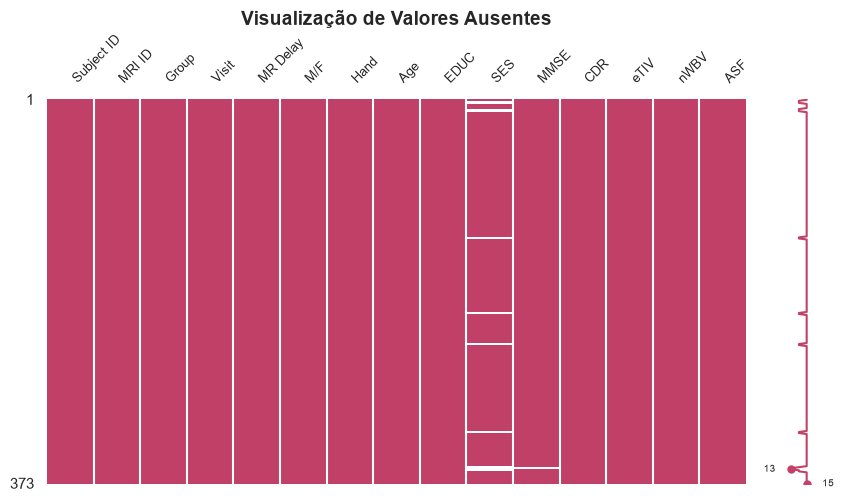

In [35]:
# Verificando tipagem e nulos

info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df)) * 100,
    'Valores Únicos': df.nunique()
})
print('\n--- Diagnóstico de Tipagem e Qualidade ---\n')
display(info_df)

nulos = df.columns[df.isna().any()].tolist()
# Armazenando colunas com valores nulos
print(f'Colunas com nulos identificadas: {nulos}')

# Grafico de nulos
msno.matrix(df, figsize=(10, 5), fontsize=9,
            color=sns.color_palette(paleta, n_colors=n_cols)[int(n_cols / 2)])
plt.title('Visualização de Valores Ausentes', fontsize=14, fontweight='bold')
plt.show()

In [36]:
# Conhecendo os dados

df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [37]:
# Conhecendo os dados

df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


In [38]:
# Conhecendo os dados

df.describe(include=['object', 'string'])

,Subject ID,MRI ID,Group,M/F,Hand
count,373,373,373,373,373
unique,150,373,3,2,1
top,OAS2_0048,OAS2_0001_MR1,Nondemented,F,R
freq,5,1,190,213,373


In [39]:
# Conhecendo os dados

df['Group'].unique()

<StringArray>
['Nondemented', 'Demented', 'Converted']
Length: 3, dtype: str

In [40]:
# Conhecendo os dados

df['M/F'].unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

In [41]:
# Conhecendo os dados

df['Hand'].unique()

<StringArray>
['R']
Length: 1, dtype: str

In [42]:
# Selecionando apenas colunas de interesse

data = df.drop(['Subject ID', 'MRI ID', 'Visit', 'MR Delay', 'Hand'], axis=1)
data.head()

,Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,M,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,Nondemented,M,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,Demented,M,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,Demented,M,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,Demented,M,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [43]:
# Variável categórica: % de group

data['Group'].value_counts(normalize=True)

Group
Nondemented    0.509383
Demented       0.391421
Converted      0.099196
Name: proportion, dtype: float64

In [44]:
# Variável categórica: tratamento de group

data['Group'] = data['Group'].map({'Demented': 1, 'Converted': 1, 'Nondemented': 0})
data.head()

,Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,0,M,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,0,M,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,1,M,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,1,M,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,1,M,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [45]:
# Variável categórica: % de gênero

data['M/F'].value_counts(normalize=True)

M/F
F    0.571046
M    0.428954
Name: proportion, dtype: float64

In [46]:
# Variável categórica: tratamento de gênero

data['M/F'] = data['M/F'].map({'M': 1, 'F': 0})
data.head()

,Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,0,1,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,0,1,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,1,1,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,1,1,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,1,1,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [47]:
# Fazendo a seleção do df sem a variável alvo (para reutilização)

var_features = [col for col in data.columns if col != var_alvo]
var_features

['M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']

In [48]:
# Calculando a matriz de correlação

corr = data.corr()
corr

,Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
Group,1.000000,0.222146,-0.005941,-0.193060,0.062463,-0.524775,0.778049,-0.042700,-0.311346,0.032495
M/F,0.222146,1.000000,-0.037726,0.089279,-0.045776,-0.166860,0.202140,0.572549,-0.249618,-0.561647
Age,-0.005941,-0.037726,1.000000,-0.027886,-0.046857,0.055612,-0.026257,0.042348,-0.518359,-0.035067
EDUC,-0.193060,0.089279,-0.027886,1.000000,-0.722647,0.194884,-0.153121,0.257015,-0.012200,-0.241752
SES,0.062463,-0.045776,-0.046857,-0.722647,1.000000,-0.149219,0.076160,-0.261575,0.090095,0.255576
MMSE,-0.524775,-0.166860,0.055612,0.194884,-0.149219,1.000000,-0.686519,-0.032084,0.341912,0.040052
CDR,0.778049,0.202140,-0.026257,-0.153121,0.076160,-0.686519,1.000000,0.022819,-0.344819,-0.029340
eTIV,-0.042700,0.572549,0.042348,0.257015,-0.261575,-0.032084,0.022819,1.000000,-0.210122,-0.988877
nWBV,-0.311346,-0.249618,-0.518359,-0.012200,0.090095,0.341912,-0.344819,-0.210122,1.000000,0.213476
ASF,0.032495,-0.561647,-0.035067,-0.241752,0.255576,0.040052,-0.029340,-0.988877,0.213476,1.000000


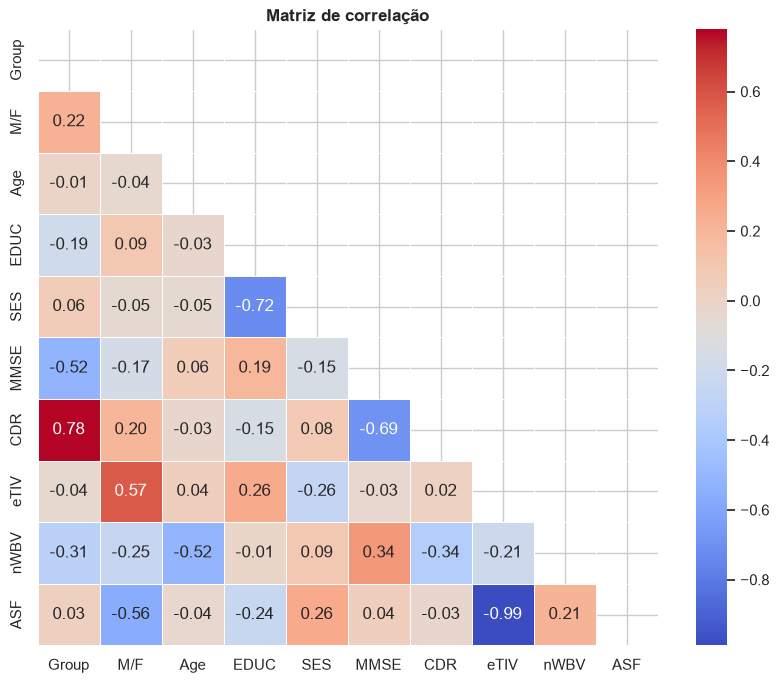

In [49]:
# Exibindo heatmap

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.title('Matriz de correlação', fontsize=12, fontweight='bold')
plt.show()

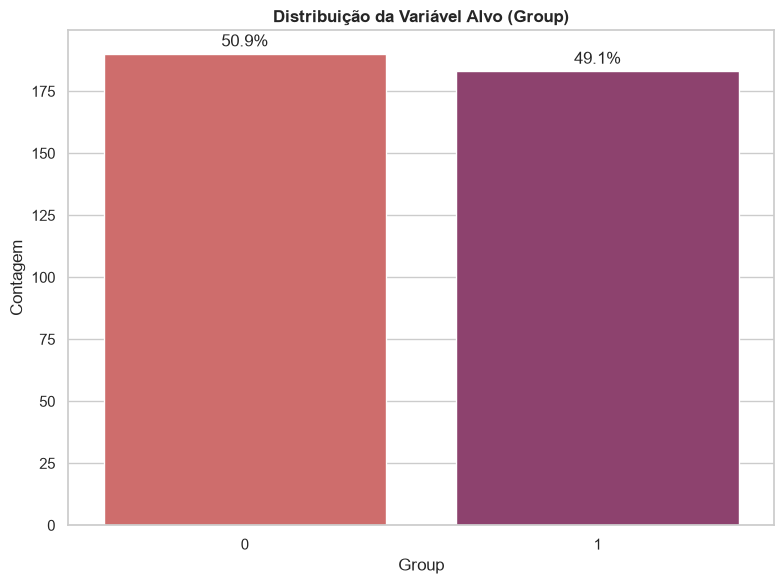

In [50]:
# Analisando distribuição e desbalanceamento de Group

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=data, x=var_alvo, palette=cores, hue=var_alvo, legend=False)
plt.title(f'Distribuição da Variável Alvo ({var_alvo})', fontsize=12, fontweight='bold')
plt.xlabel(f'{var_alvo}')
plt.ylabel('Contagem')

# Adicionando porcentagens nas barras
total = len(data)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{(height/total)*100:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', xytext=(0, 3),
                textcoords='offset points')
plt.tight_layout()
plt.show()

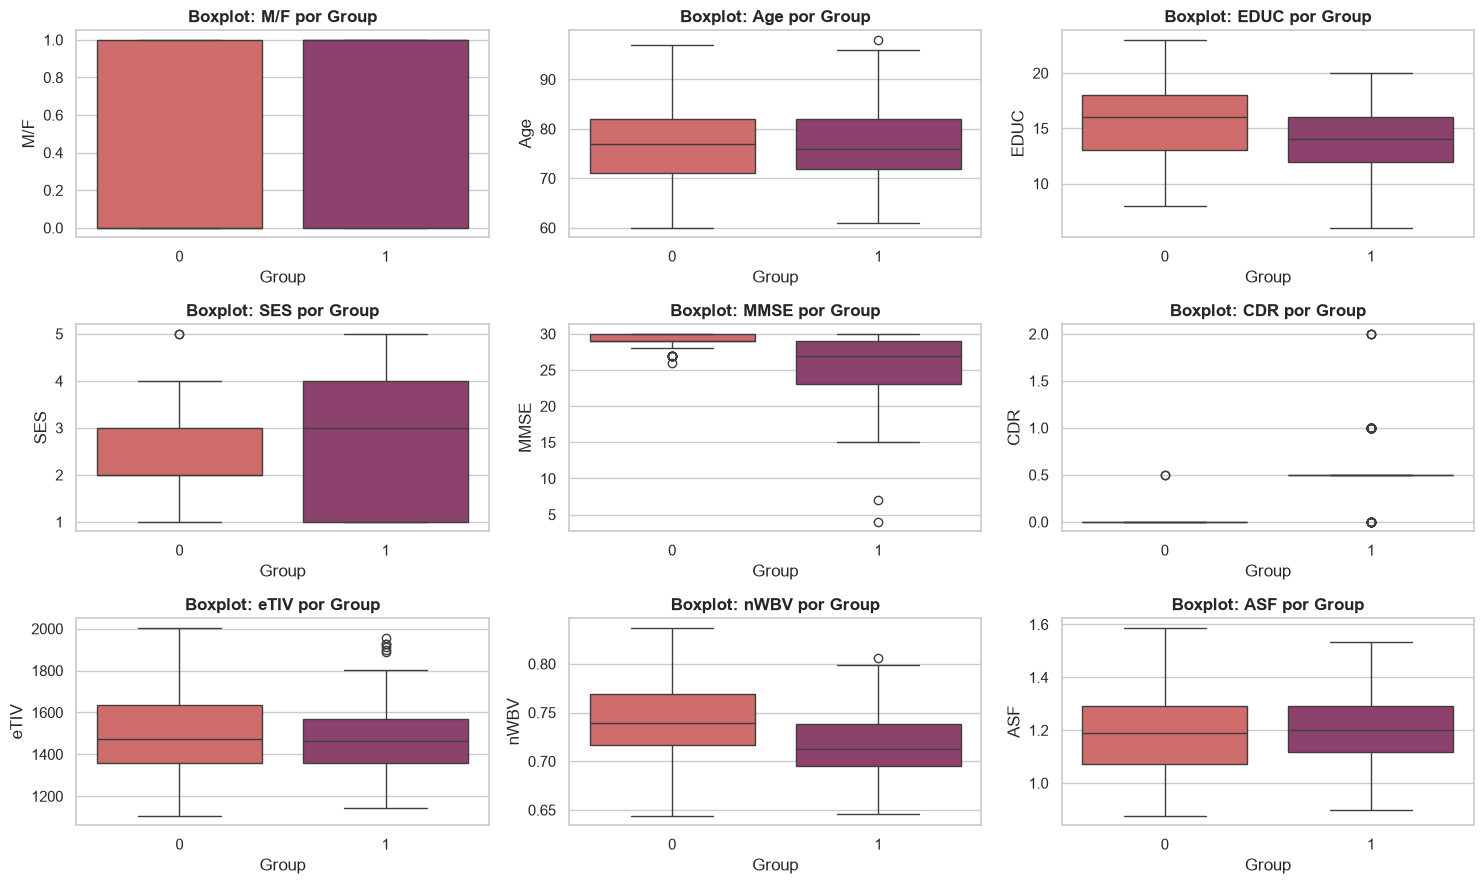

In [51]:
# Boxplots

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(var_features):
    sns.boxplot(data=data, x=var_alvo, y=var, ax=axes[i], palette=cores, hue=var_alvo, legend=False)
    axes[i].set_title(f'Boxplot: {var} por {var_alvo}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

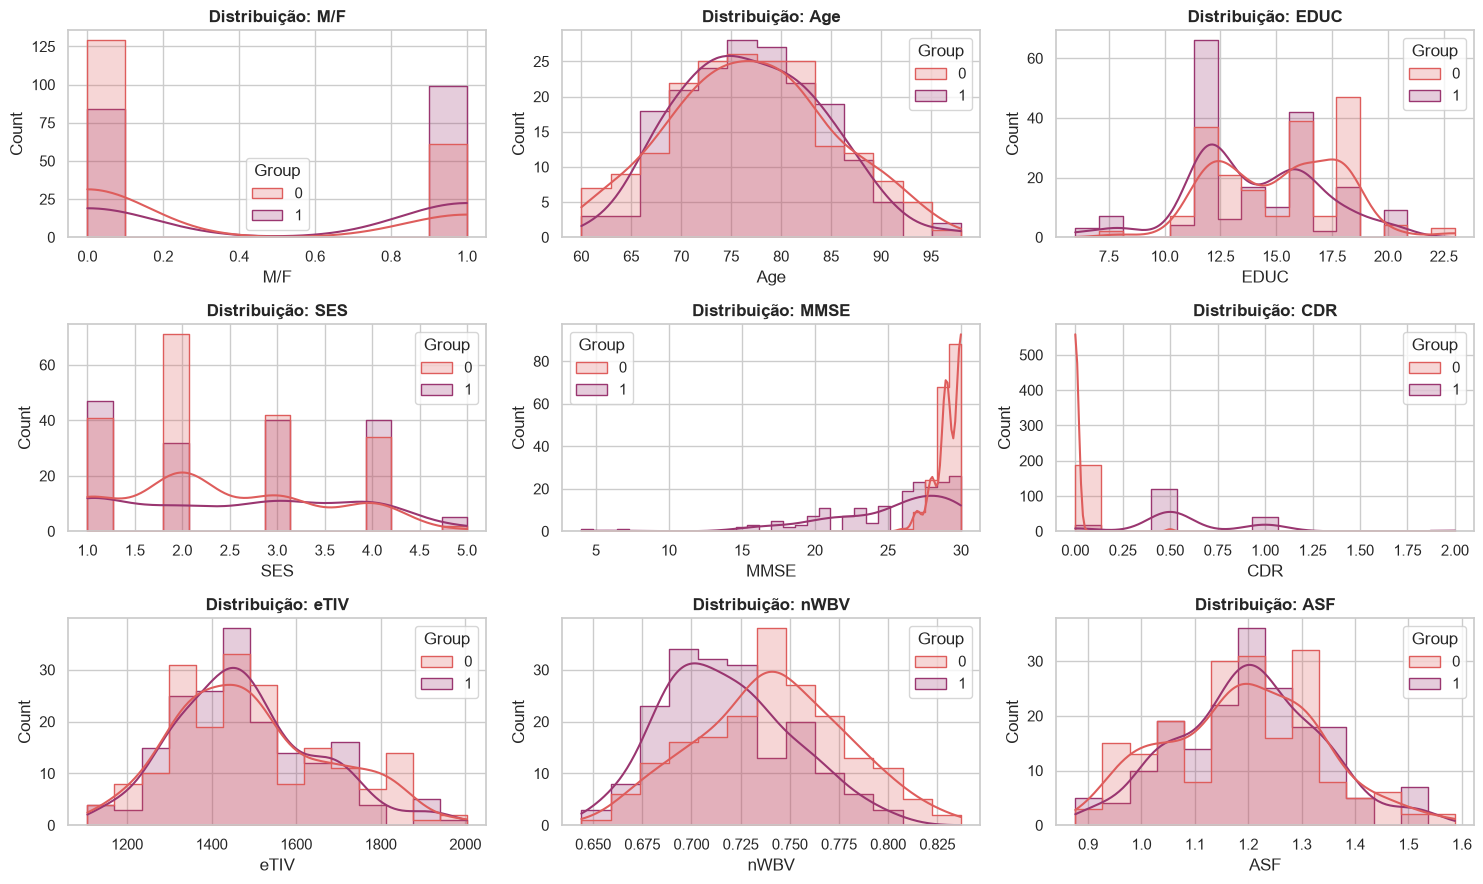

In [52]:
# Histogramas

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(var_features):
    sns.histplot(data=data, x=var, hue=var_alvo, kde=True, ax=axes[i], palette=cores, element='step')
    axes[i].set_title(f'Distribuição: {var}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

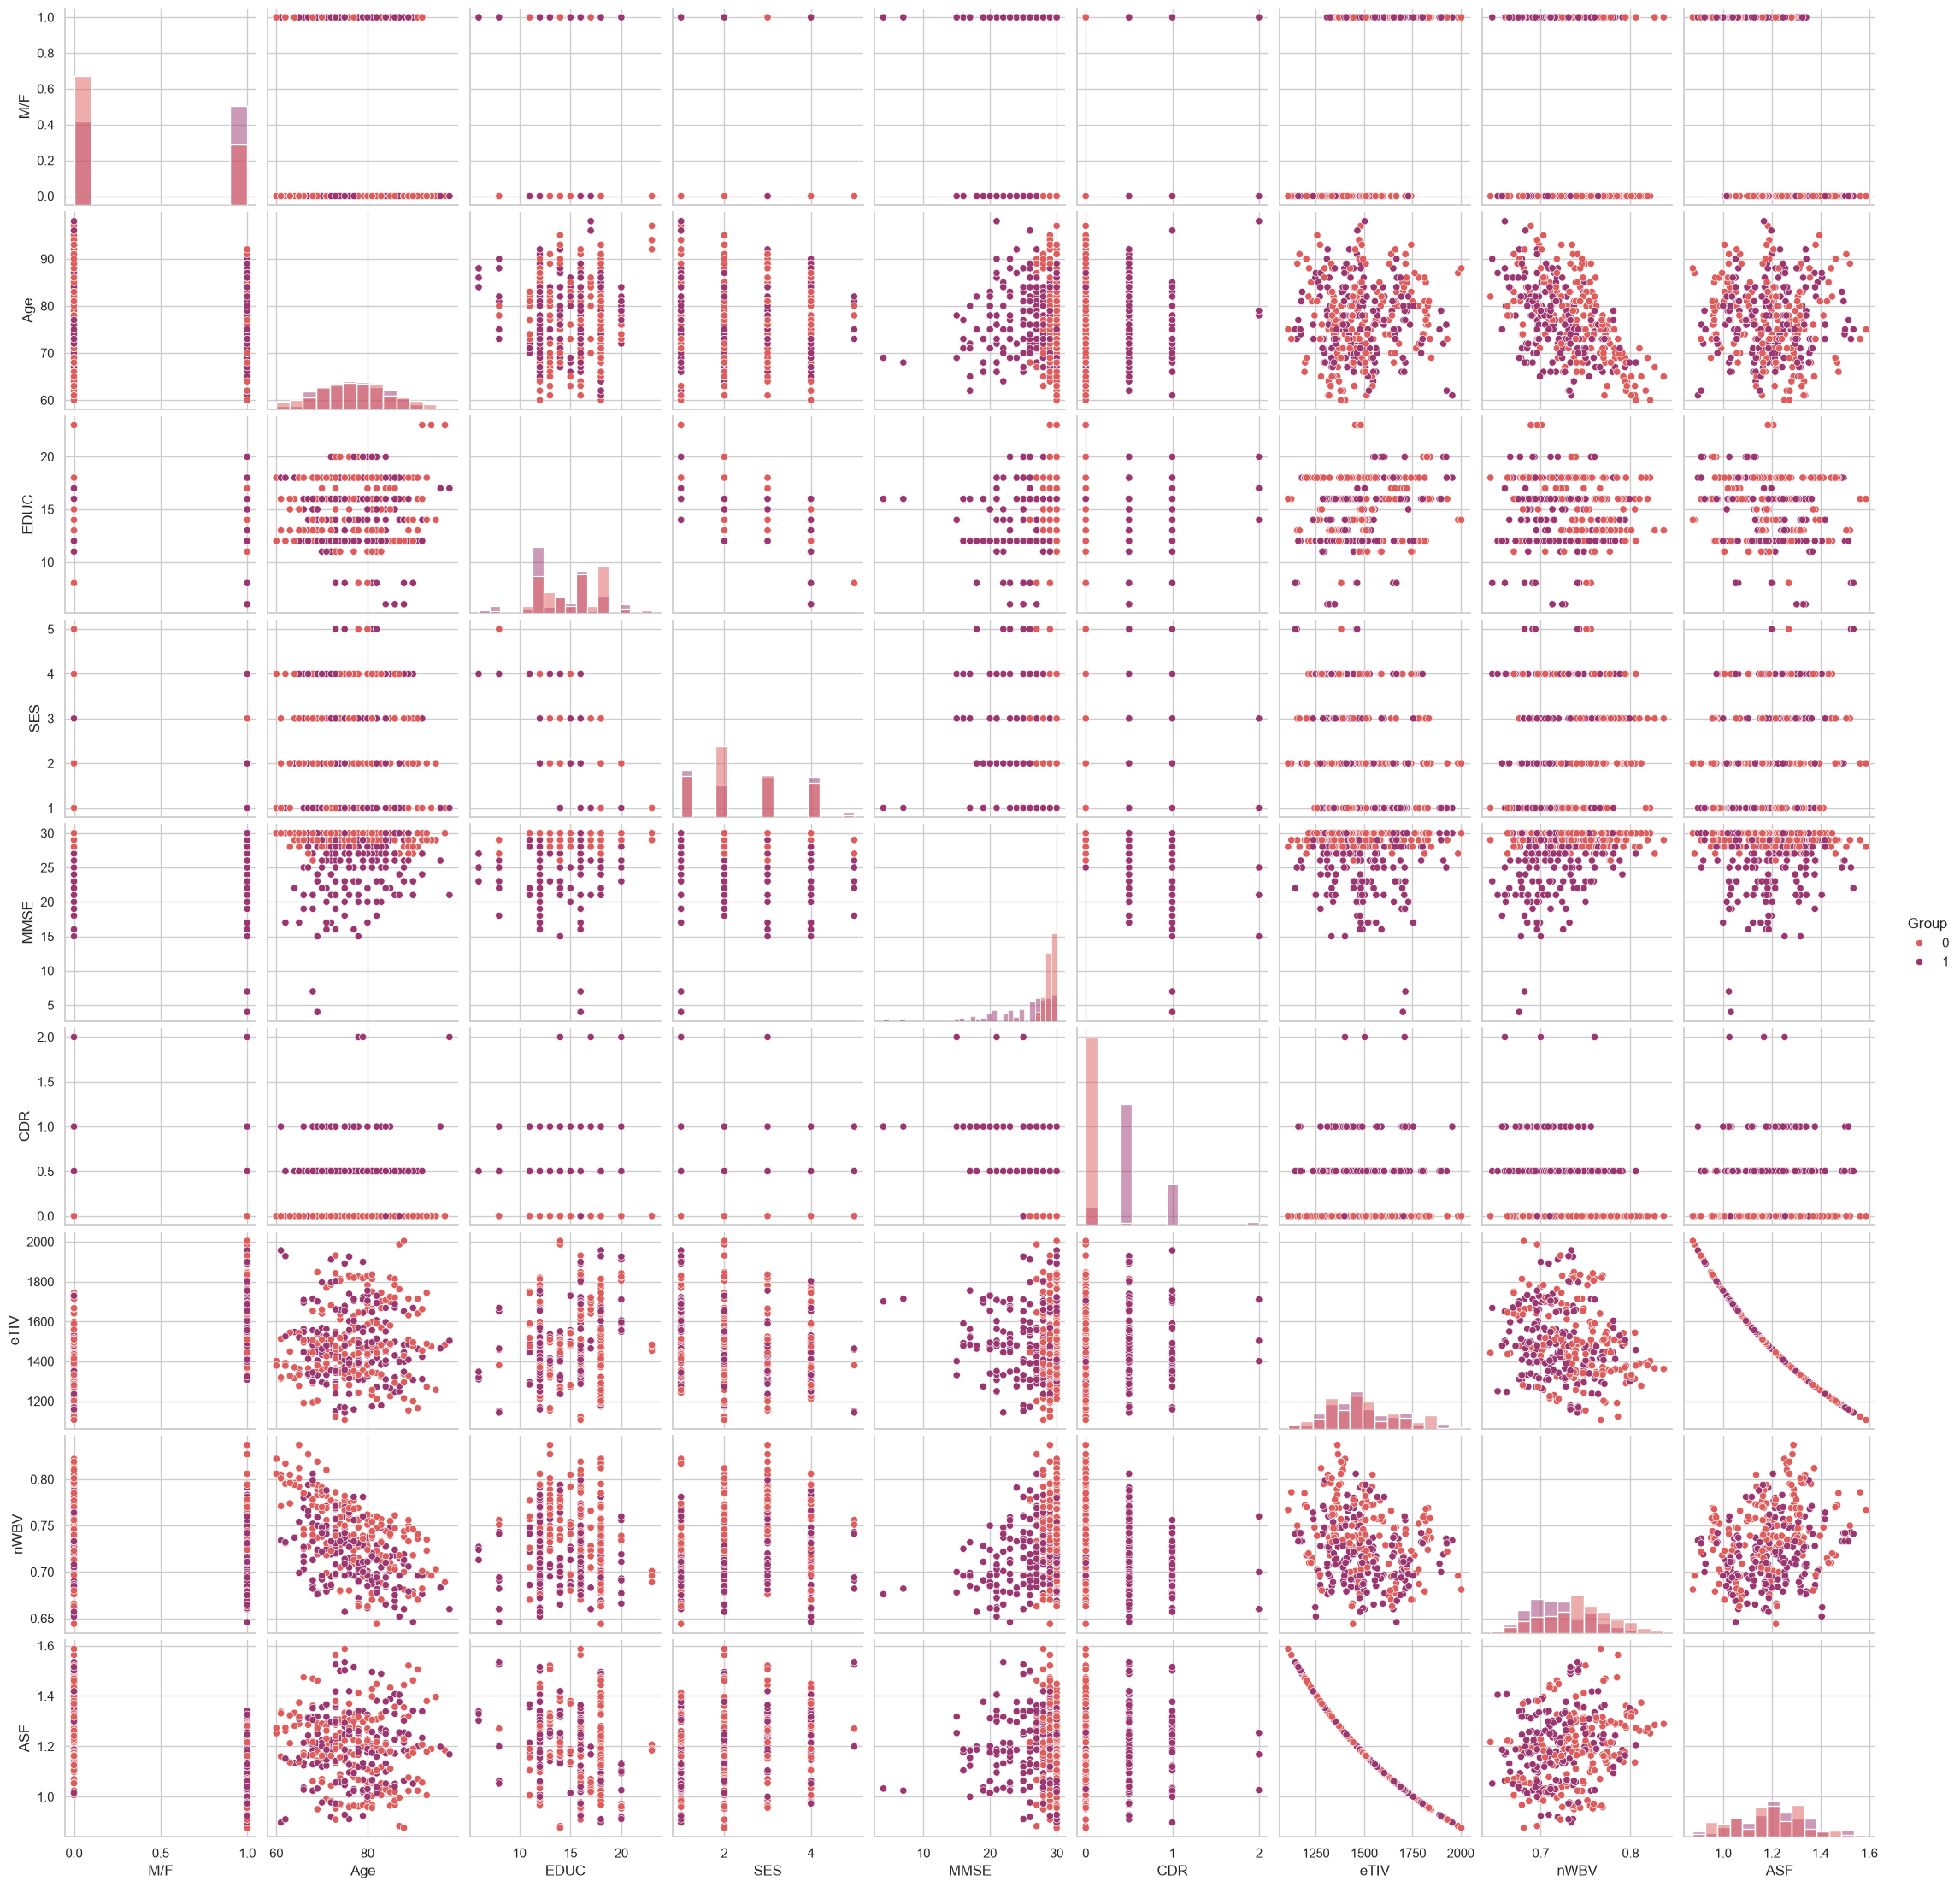

In [53]:
# Exibindo dispersões

sns.pairplot(data, hue=var_alvo, diag_kind='hist', palette=cores)

In [54]:
# Ranqueando os principais preditores

corr_rank = corr['Group'].abs().drop('Group').sort_values(ascending=False)
corr_rank

CDR     0.778049
MMSE    0.524775
nWBV    0.311346
M/F     0.222146
EDUC    0.193060
SES     0.062463
eTIV    0.042700
ASF     0.032495
Age     0.005941
Name: Group, dtype: float64

In [55]:
display(Markdown(
        f'Com base na análise exploratória e no ranqueamento de correlação linear, os principais candidatos a preditores da variável alvo {var_alvo} são:\n'
        f'- {corr_rank.index[0]} (|r| = {corr_rank.iloc[0]:.2f}), \n'
        f'- {corr_rank.index[1]} (|r| = {corr_rank.iloc[1]:.2f}) e \n'
        f'- {corr_rank.index[2]} (|r| = {corr_rank.iloc[2]:.2f}).\n\n'
        f'Adicionalmente, as variáveis {corr_rank.index[3]} (|r| = {corr_rank.iloc[3]:.2f}) e {corr_rank.index[4]} (|r| = {corr_rank.iloc[4]:.2f}) demonstram associação intermediária, enquanto as demais características ({', '.join(corr_rank.index[5:])}) apresentam fraca correlação linear direta (|r| < 0.10) com o diagnóstico do grupo.'
))

Com base na análise exploratória e no ranqueamento de correlação linear, os principais candidatos a preditores da variável alvo Group são:
- CDR (|r| = 0.78), 
- MMSE (|r| = 0.52) e 
- nWBV (|r| = 0.31).

Adicionalmente, as variáveis M/F (|r| = 0.22) e EDUC (|r| = 0.19) demonstram associação intermediária, enquanto as demais características (SES, eTIV, ASF, Age) apresentam fraca correlação linear direta (|r| < 0.10) com o diagnóstico do grupo.

## 3. Modelo de ML

Optamos por separar 75% dos dados para treino e 25% para teste.

In [56]:
def tratar_nulos(dados_treino, dados_teste=None, tendencia='media'):
  """
  Trata valores ausentes usando a moda, calculada apenas no treino
  e aplicada em treino e teste (evita vazamento de dados).

  Parametros:
    dados_treino (pd.DataFrame): conjunto de treino.
    dados_teste (pd.DataFrame, opcional): conjunto de teste.
    tendencia (str, opcional): 'media', 'mediana' ou 'moda'. Padrao: 'media'.

  Retorno: tupla (X_train, X_test) com nulos preenchidos.
  """
  colunas_com_nulo = dados_treino.columns[dados_treino.isna().any()].tolist()

  for col in colunas_com_nulo:
    if tendencia == 'mediana':
      valor_tendencia = dados_treino[col].median()
    elif tendencia == 'moda':
      valor_tendencia = dados_treino[col].mode()[0]
    else:
      valor_tendencia = dados_treino[col].mean()

    dados_treino[col] = dados_treino[col].fillna(valor_tendencia)

    if dados_teste is not None:
      dados_teste[col] = dados_teste[col].fillna(valor_tendencia)

  return dados_treino, dados_teste


def preprocessar_dados(dados, alvo, test_size=0.2, random_state=42):
  """
  Preprocessa o dataframe para modelagem:
  1. Separa variaveis preditoras (X) e alvo (y).
  2. Faz a separacao estratificada dos dados em treino e teste.
  3. Normaliza as variaveis usando StandardScaler (ajustado no treino).
  4. Reconstroi dfs normalizados com colunas e indices originais.

  Parametros:
    dados (pd.DataFrame): df de entrada, ja tratado.
    alvo (str): nome da coluna davariavel alvo.
    test_size (float, opcional): proporcao dos dados para o conjunto de teste. Padrao: 0.2.

  Retorno: tupla: (X_train_scaled, X_test_scaled, y_train, y_test)
  """

  # Separa as variaveis para treino e teste
  X = dados.drop(columns=[alvo])
  y = dados[alvo]

  X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
  )

  # Trata nulos: moda calculada SO no treino, aplicada nos dois
  X_train, X_test = tratar_nulos(X_train, X_test, 'moda')

  # Normaliza com StandardScaler pra nao vazar dado
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)    # fit + transform no treino
  X_test_scaled = scaler.transform(X_test)          # so transform no teste

  # Traz o df de volta com os nomes das colunas e indices originais
  X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
  X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

  return X_train_scaled, X_test_scaled, y_train, y_test

In [57]:
X_train_scaled, X_test_scaled, y_train, y_test = preprocessar_dados(data.drop(['CDR'], axis=1), 'Group', 0.25)

print(f'Tamanho do conjunto de treino: {X_train_scaled.shape[0]} amostras')
print(f'Tamanho do conjunto de teste: {X_test_scaled.shape[0]} amostras')

Tamanho do conjunto de treino: 279 amostras
Tamanho do conjunto de teste: 94 amostras


## Modelagem Preditiva - Pergunta 2

Nesta etapa, instanciamos os três algoritmos solicitados (Regressão Logística, Árvore de Decisão e Random Forest).

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Instanciando e treinando
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predições
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Métricas
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log, pos_label=1)
rec_log = recall_score(y_test, y_pred_log, pos_label=1)
f1_log = f1_score(y_test, y_pred_log, pos_label=1)
auc_log = roc_auc_score(y_test, y_prob_log)

print("Regressão Logística treinada com sucesso!")

Regressão Logística treinada com sucesso!


Treinamento e Cálculo de Métricas

In [59]:
from sklearn.tree import DecisionTreeClassifier

# Instanciando e treinando
dt_tree = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_tree.fit(X_train_scaled, y_train)

# Predições
y_pred_dt = dt_tree.predict(X_test_scaled)
y_prob_dt = dt_tree.predict_proba(X_test_scaled)[:, 1]

# Métricas
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, pos_label=1)
rec_dt = recall_score(y_test, y_pred_dt, pos_label=1)
f1_dt = f1_score(y_test, y_pred_dt, pos_label=1)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Árvore de Decisão treinada com sucesso!")

Árvore de Decisão treinada com sucesso!


In [60]:
from sklearn.ensemble import RandomForestClassifier

# Instanciando e treinando
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
rf_clf.fit(X_train_scaled, y_train)

# Predições
y_pred_rf = rf_clf.predict(X_test_scaled)
y_prob_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

# Métricas
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, pos_label=1)
rec_rf = recall_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest treinado com sucesso!")

Random Forest treinado com sucesso!


Exibição da Tabela Comparativa

In [65]:
import pandas as pd
from IPython.display import display

dados_comparativos = {
    "Modelo": ["Regressão Logística", "Árvore de Decisão", "Random Forest"],
    "Acurácia": [acc_log, acc_dt, acc_rf],
    "Precisão": [prec_log, prec_dt, prec_rf],
    "Recall (Sensibilidade)": [rec_log, rec_dt, rec_rf],
    "F1-Score": [f1_log, f1_dt, f1_rf],
    "AUC-ROC": [auc_log, auc_dt, auc_rf]
}

df_comparativo = pd.DataFrame(dados_comparativos).set_index("Modelo")

tabela_estilizada = (
    df_comparativo.style
    # Define fundo branco e texto escuro para TODAS as células do corpo
    .set_properties(**{
        'background-color': '#ffffff',
        'color': '#212529',
        'padding': '8px',
        'text-align': 'center'
    })
    # Aplica a cor de destaque (rosa/coral) por cima nos maiores valores de cada coluna
    .highlight_max(axis=0, color='#fde2e4')
    .format({
        "Acurácia": "{:.1%}",
        "Precisão": "{:.1%}",
        "Recall (Sensibilidade)": "{:.1%}",
        "F1-Score": "{:.1%}",
        "AUC-ROC": "{:.3f}"
    })
    .set_caption("<b>Tabela Comparativa de Desempenho dos Modelos de ML</b>")
    .set_table_styles([
        # Título
        {'selector': 'caption', 'props': [
            ('font-size', '14px'), 
            ('text-align', 'center'), 
            ('margin-bottom', '10px'),
            ('color', '#ffffff'), # Texto do título em branco para se destacar no tema escuro
            ('font-weight', 'bold')
        ]},
        # Cabeçalho da tabela e coluna de índices
        {'selector': 'th', 'props': [
            ('background-color', '#f1f3f5'), 
            ('color', '#212529'), 
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('padding', '8px')
        ]},
        # Borda da tabela
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('border', '1px solid #dee2e6')
        ]}
    ])
)

display(tabela_estilizada)

,Acurácia,Precisão,Recall (Sensibilidade),F1-Score,AUC-ROC
Modelo,,,,,
Regressão Logística,76.6%,78.6%,71.7%,75.0%,0.883
Árvore de Decisão,71.3%,77.1%,58.7%,66.7%,0.772
Random Forest,78.7%,86.1%,67.4%,75.6%,0.853


A tabela apresenta o comparativo de métricas dos três modelos testados (**Regressão Logística**, **Árvore de Decisão** e **Random Forest**). Como o objetivo é prever sinais de demência, a avaliação foca especialmente na **Classe 1 (Demented/Converted)** — pacientes identificados com declínio cognitivo — mantendo o equilíbrio em relação à **Classe 0 (Nondemented)**.

### Interpretação das Métricas Chave:

* **Recall (Sensibilidade) da Classe 1:** Métrica crítica no contexto da saúde, pois indica a capacidade de identificar corretamente os pacientes doentes e evitar falsos negativos.
  * A **Regressão Logística** obteve o maior Recall (**71,7%**), seguida pelo **Random Forest** (**67,4%**) e pela **Árvore de Decisão** (**58,7%**).

* **Precisão (Precision) da Classe 1:** Mede a confiabilidade de um diagnóstico positivo (evitar alarmes falsos em pacientes saudáveis).
  * O **Random Forest** destacou-se com a maior precisão (**86,1%**), seguido pela **Regressão Logística** (**78,6%**) e pela **Árvore de Decisão** (**77,1%**).

* **Acurácia Geral e AUC-ROC:**
  * O **Random Forest** alcançou a melhor **Acurácia Geral** (**78,7%**) e o maior **F1-Score** (**75,6%**).
  * A **Regressão Logística** obteve a melhor capacidade de separação global (**AUC-ROC de 0.883**).